# CPU Architecture

Explore CPU topology, heterogeneous cores, and their implications for measured performance.

## Objectives

Identify logical CPUs and core types, then design a controlled comparison of CPU execution.

## Background

Modern heterogeneous CPUs combine core classes with different performance and efficiency characteristics. Scheduling and affinity can therefore affect repeatability.

## Prediction

TODO: Predict how the observed core topology or affinity will affect a simple CPU workload.

## Environment

In [1]:
import os
import platform
import socket
import sys
from pathlib import Path

repository_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").is_file()
    ),
    None,
)
if repository_root is None:
    raise RuntimeError("Run this notebook from within the repository")
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Hostname: {socket.gethostname()}")
print(f"Working directory: {os.getcwd()}")

Python: 3.14.3 (main, Feb 12 2026, 00:45:04) [Clang 21.1.4 ]
Platform: Linux-6.17.0-1026-nvidia-aarch64-with-glibc2.39
Hostname: spark-0240
Working directory: /home/coert/workspace/dgx-spark-lab/experiments/00-foundations


## Experiment

In [2]:
from pathlib import Path

import pandas as pd

from common.cpu import read_proc_file


ARM_PART_NAMES = {
    "0xd87": "Cortex-A725",
    "0xd85": "Cortex-X925",
}


def parse_cpuinfo(text: str) -> dict[int, dict[str, str]]:
    """Parse /proc/cpuinfo into fields indexed by logical CPU number."""
    cpus: dict[int, dict[str, str]] = {}

    for block in text.strip().split("\n\n"):
        fields: dict[str, str] = {}

        for line in block.splitlines():
            if ":" not in line:
                continue

            key, value = line.split(":", maxsplit=1)
            fields[key.strip()] = value.strip()

        processor = fields.get("processor")
        if processor is not None:
            cpus[int(processor)] = fields

    return cpus


def read_optional(path: Path) -> str | None:
    """Read and strip a sysfs value, returning None when unavailable."""
    try:
        return path.read_text().strip()
    except (FileNotFoundError, PermissionError, OSError):
        return None


def as_mhz(khz: str | None) -> float | None:
    """Convert a sysfs frequency in kHz to MHz."""
    if khz is None:
        return None
    return int(khz) / 1_000


cpuinfo = parse_cpuinfo(read_proc_file("cpuinfo"))
rows = []

for cpu_id, fields in sorted(cpuinfo.items()):
    cpu_root = Path(f"/sys/devices/system/cpu/cpu{cpu_id}")

    part = fields.get("CPU part", "").lower()

    rows.append(
        {
            "cpu": cpu_id,
            "arm_part": part,
            "core_type": ARM_PART_NAMES.get(part, "Unknown"),
            "max_mhz": as_mhz(read_optional(cpu_root / "cpufreq/cpuinfo_max_freq")),
            "min_mhz": as_mhz(read_optional(cpu_root / "cpufreq/cpuinfo_min_freq")),
            "current_mhz": as_mhz(read_optional(cpu_root / "cpufreq/scaling_cur_freq")),
            "capacity": read_optional(cpu_root / "cpu_capacity"),
            "package_id": read_optional(cpu_root / "topology/physical_package_id"),
            "cluster_id": read_optional(cpu_root / "topology/cluster_id"),
            "core_id": read_optional(cpu_root / "topology/core_id"),
            "l2_cache_id": read_optional(cpu_root / "cache/index2/id"),
            "l3_cache_id": read_optional(cpu_root / "cache/index3/id"),
        }
    )

topology = pd.DataFrame(rows)

for column in [
    "capacity",
    "package_id",
    "cluster_id",
    "core_id",
    "l2_cache_id",
    "l3_cache_id",
]:
    topology[column] = pd.to_numeric(topology[column], errors="coerce").astype("Int64")

topology

,cpu,arm_part,core_type,max_mhz,min_mhz,current_mhz,capacity,package_id,cluster_id,core_id,l2_cache_id,l3_cache_id
0,0,0xd87,Cortex-A725,2808.0,338.0,2808.0,718,36,56,0,<NA>,<NA>
1,1,0xd87,Cortex-A725,2808.0,338.0,2808.0,718,36,56,1,<NA>,<NA>
2,2,0xd87,Cortex-A725,2808.0,338.0,2808.0,718,36,56,2,<NA>,<NA>
3,3,0xd87,Cortex-A725,2808.0,338.0,2808.0,718,36,56,3,<NA>,<NA>
4,4,0xd87,Cortex-A725,2808.0,338.0,2808.0,718,36,56,4,<NA>,<NA>
5,5,0xd85,Cortex-X925,3900.0,1378.0,3900.0,997,36,56,5,<NA>,<NA>
6,6,0xd85,Cortex-X925,3900.0,1378.0,3900.0,997,36,56,6,<NA>,<NA>
7,7,0xd85,Cortex-X925,3900.0,1378.0,3900.0,997,36,56,7,<NA>,<NA>
8,8,0xd85,Cortex-X925,3900.0,1378.0,3900.0,997,36,56,8,<NA>,<NA>
9,9,0xd85,Cortex-X925,3900.0,1378.0,3900.0,997,36,56,9,<NA>,<NA>


In [3]:
from pathlib import Path

import pandas as pd


def read_optional(path: Path) -> str | None:
    try:
        return path.read_text().strip()
    except (FileNotFoundError, PermissionError, OSError):
        return None


cache_rows = []

for cpu_id in topology["cpu"]:
    cache_root = Path(f"/sys/devices/system/cpu/cpu{cpu_id}/cache")

    for index_path in sorted(cache_root.glob("index*")):
        cache_rows.append(
            {
                "cpu": cpu_id,
                "index": index_path.name,
                "level": read_optional(index_path / "level"),
                "type": read_optional(index_path / "type"),
                "size": read_optional(index_path / "size"),
                "cache_id": read_optional(index_path / "id"),
                "shared_cpu_list": read_optional(index_path / "shared_cpu_list"),
            }
        )

cache_topology = pd.DataFrame(cache_rows)

cache_topology

,cpu,index,level,type,size,cache_id,shared_cpu_list
0,0,index0,1,Data,64K,None,0
1,0,index1,1,Instruction,64K,None,0
2,0,index2,2,Unified,512K,None,0
3,0,index3,3,Unified,8192K,None,0-9
4,1,index0,1,Data,64K,None,1
...,...,...,...,...,...,...,...
75,18,index3,3,Unified,16384K,None,10-19
76,19,index0,1,Data,64K,None,19
77,19,index1,1,Instruction,64K,None,19
78,19,index2,2,Unified,2048K,None,19


In [4]:
cache_topology.query("level == '3'")[
    [
        "cpu",
        "index",
        "level",
        "type",
        "size",
        "cache_id",
        "shared_cpu_list",
    ]
].drop_duplicates(subset=["cache_id", "shared_cpu_list"])

,cpu,index,level,type,size,cache_id,shared_cpu_list
3,0,index3,3,Unified,8192K,None,0-9
43,10,index3,3,Unified,16384K,None,10-19


In [5]:
MASK_64 = (1 << 64) - 1


def integer_workload(iterations: int = 500_000) -> int:
    """Run deterministic, single-threaded integer work with a tiny working set."""
    value = 0x9E3779B97F4A7C15

    for index in range(iterations):
        value ^= index + 0x9E3779B97F4A7C15 + ((value << 6) & MASK_64) + (value >> 2)
        value &= MASK_64

    return value


# Sanity check: the workload must be deterministic.
assert integer_workload(10_000) == integer_workload(10_000)

In [6]:
import os
from collections.abc import Generator
from contextlib import contextmanager


@contextmanager
def pinned_to_cpu(cpu_id: int) -> Generator[None]:
    """Temporarily restrict the current process to one logical CPU."""
    original_affinity = os.sched_getaffinity(0)

    if cpu_id not in original_affinity:
        raise ValueError(
            f"CPU {cpu_id} is not available in the current affinity set "
            f"{sorted(original_affinity)}"
        )

    try:
        os.sched_setaffinity(0, {cpu_id})

        active_affinity = os.sched_getaffinity(0)
        if active_affinity != {cpu_id}:
            raise RuntimeError(
                f"Could not pin process to CPU {cpu_id}: "
                f"active affinity is {sorted(active_affinity)}"
            )

        yield
    finally:
        os.sched_setaffinity(0, original_affinity)

In [7]:
original_affinity = os.sched_getaffinity(0)
test_cpu = min(original_affinity)

print("Before:", sorted(os.sched_getaffinity(0)))

with pinned_to_cpu(test_cpu):
    print("Inside:", sorted(os.sched_getaffinity(0)))
    assert os.sched_getaffinity(0) == {test_cpu}

print("After:", sorted(os.sched_getaffinity(0)))
assert os.sched_getaffinity(0) == original_affinity

Before: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Inside: [0]
After: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [8]:
from common.benchmark import benchmark_callable


calibration = benchmark_callable(
    integer_workload,
    warmup_iterations=1,
    iterations=3,
)

print(f"Median: {calibration.median_ns / 1_000_000:.2f} ms")
print(f"Minimum: {calibration.minimum_ns / 1_000_000:.2f} ms")
print(f"Maximum: {calibration.maximum_ns / 1_000_000:.2f} ms")

Median: 63.62 ms
Minimum: 63.54 ms
Maximum: 63.76 ms


In [9]:
import random

from common.benchmark import benchmark_callable


WORKLOAD_ITERATIONS = 500_000
WARMUP_ITERATIONS = 2
MEASURED_ITERATIONS = 10

cpu_order = topology["cpu"].astype(int).tolist()
random.Random(20260728).shuffle(cpu_order)

benchmark_rows = []

for cpu_id in cpu_order:
    cpu_metadata = topology.loc[topology["cpu"] == cpu_id].iloc[0]

    with pinned_to_cpu(cpu_id):
        result = benchmark_callable(
            integer_workload,
            WORKLOAD_ITERATIONS,
            warmup_iterations=WARMUP_ITERATIONS,
            iterations=MEASURED_ITERATIONS,
        )

    benchmark_rows.append(
        {
            "cpu": cpu_id,
            "core_type": cpu_metadata["core_type"],
            "cluster_id": cpu_metadata["cluster_id"],
            "max_mhz": cpu_metadata["max_mhz"],
            "minimum_ms": result.minimum_ns / 1_000_000,
            "median_ms": result.median_ns / 1_000_000,
            "mean_ms": result.mean_ns / 1_000_000,
            "maximum_ms": result.maximum_ns / 1_000_000,
            "stddev_ms": result.standard_deviation_ns / 1_000_000,
        }
    )

benchmark_results = (
    pd.DataFrame(benchmark_rows).sort_values("cpu").reset_index(drop=True)
)

benchmark_results

,cpu,core_type,cluster_id,max_mhz,minimum_ms,median_ms,mean_ms,maximum_ms,stddev_ms
0,0,Cortex-A725,56,2808.0,133.163175,133.774543,133.818656,134.383369,0.398726
1,1,Cortex-A725,56,2808.0,132.921445,133.228502,133.185679,133.437415,0.185091
2,2,Cortex-A725,56,2808.0,127.192553,127.600842,127.647453,128.430268,0.416443
3,3,Cortex-A725,56,2808.0,146.376963,146.615412,146.819874,147.531141,0.422490
4,4,Cortex-A725,56,2808.0,134.121046,134.647312,134.772947,135.691866,0.484505
5,5,Cortex-X925,56,3900.0,67.658845,67.673654,67.714420,67.882574,0.067879
6,6,Cortex-X925,56,3900.0,64.947047,65.178416,65.187195,65.408665,0.145107
7,7,Cortex-X925,56,3900.0,67.646206,67.740037,67.737885,67.903645,0.071823
8,8,Cortex-X925,56,3900.0,67.695854,67.772773,67.795748,67.934718,0.075566
9,9,Cortex-X925,56,3900.0,66.571946,66.602771,66.604313,66.659371,0.023928


In [10]:
group_summary = (
    benchmark_results.groupby(
        ["cluster_id", "core_type"],
        dropna=False,
    )
    .agg(
        cpu_count=("cpu", "count"),
        cpu_ids=("cpu", list),
        median_of_medians_ms=("median_ms", "median"),
        fastest_ms=("minimum_ms", "min"),
        mean_stddev_ms=("stddev_ms", "mean"),
    )
    .reset_index()
)

group_summary

,cluster_id,core_type,cpu_count,cpu_ids,median_of_medians_ms,fastest_ms,mean_stddev_ms
0,56,Cortex-A725,5,"[0, 1, 2, 3, 4]",133.774543,127.192553,0.381451
1,56,Cortex-X925,5,"[5, 6, 7, 8, 9]",67.673654,64.947047,0.076861
2,1144,Cortex-A725,5,"[10, 11, 12, 13, 14]",133.443638,127.075320,0.343132
3,1144,Cortex-X925,5,"[15, 16, 17, 18, 19]",65.620640,64.297670,0.171243


In [11]:
core_type_comparison = group_summary.pivot(
    index="cluster_id",
    columns="core_type",
    values="median_of_medians_ms",
).reset_index()

core_type_comparison["x925_speedup"] = (
    core_type_comparison["Cortex-A725"] / core_type_comparison["Cortex-X925"]
)

core_type_comparison["x925_percent_faster"] = (
    core_type_comparison["x925_speedup"] - 1
) * 100

core_type_comparison

core_type,cluster_id,Cortex-A725,Cortex-X925,x925_speedup,x925_percent_faster
0,56,133.774543,67.673654,1.976760,97.675959
1,1144,133.443638,65.620640,2.033562,103.356198


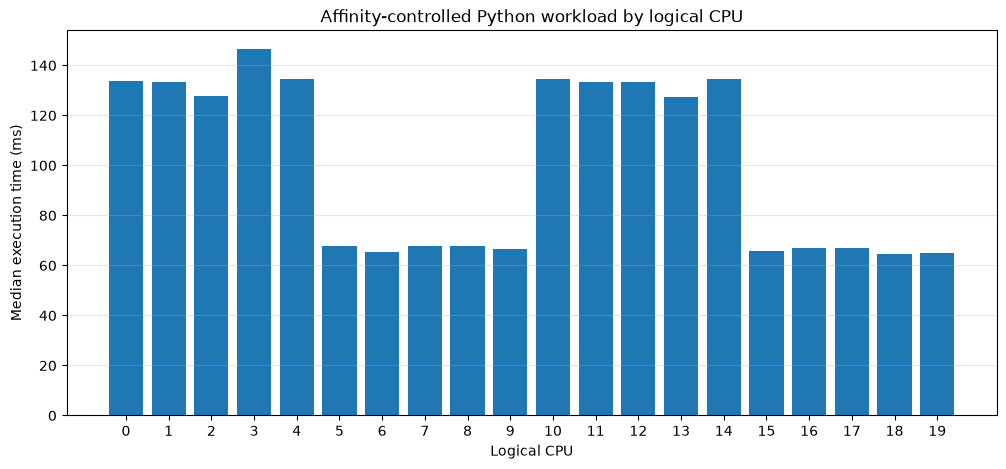

In [12]:
import matplotlib.pyplot as plt


plot_data = benchmark_results.sort_values("cpu")

figure, axis = plt.subplots(figsize=(12, 5))

axis.bar(
    plot_data["cpu"].astype(str),
    plot_data["median_ms"],
)

axis.set_title("Affinity-controlled Python workload by logical CPU")
axis.set_xlabel("Logical CPU")
axis.set_ylabel("Median execution time (ms)")
axis.grid(axis="y", alpha=0.3)

plt.show()

In [13]:
cluster_comparison = group_summary.pivot(
    index="core_type",
    columns="cluster_id",
    values="median_of_medians_ms",
).reset_index()

cluster_comparison["cluster_1144_speedup"] = (
    cluster_comparison[56] / cluster_comparison[1144]
)

cluster_comparison["cluster_1144_percent_faster"] = (
    cluster_comparison["cluster_1144_speedup"] - 1
) * 100

cluster_comparison

cluster_id,core_type,56,1144,cluster_1144_speedup,cluster_1144_percent_faster
0,Cortex-A725,133.774543,133.443638,1.002480,0.247974
1,Cortex-X925,67.673654,65.620640,1.031286,3.128609


## Observations

The 20 logical CPUs are divided into two L3-sharing domains. CPUs 0–9 share an 8 MiB unified L3 cache, while CPUs 10–19 share a 16 MiB unified L3 cache. Each domain contains five Cortex-A725 and five Cortex-X925 cores. Therefore, the two CPU clusters differ not only in identifier but also in shared-cache capacity.

Under explicit CPU affinity, the Cortex-X925 cores completed the single-threaded Python integer workload in approximately half the time required by the Cortex-A725 cores. The measured speedup was 2.001× in cluster 56 and 1.985× in cluster 1144. The similarity across clusters indicates that core type dominated this small-working-set benchmark, while the unequal 8 MiB and 16 MiB L3 capacities had little apparent effect.

Across two runs, Cortex-X925 cores completed the affinity-pinned Python workload in approximately half the time of Cortex-A725 cores. The measured X925 speedup ranged from about 1.99× to 2.12×. Small differences between clusters were not stable: cluster 1144 was faster for some core-type/run combinations and slower for others.

## Explanation

A 2× speedup means the X925 completes approximately twice as many instances of this workload per unit time. Equivalently, it requires about 50% less elapsed time per invocation. Because the maximum-frequency ratio is only about 1.39×, the remaining advantage must arise from workload-dependent microarchitectural performance rather than clock frequency alone.

The stable separation between A725 and X925 indicates a strong core-class effect. By contrast, the small cluster-to-cluster differences changed magnitude and, for the A725 cores, direction between runs. These differences are therefore more plausibly measurement noise or transient system-state effects than a reproducible property of the 8 MiB versus 16 MiB L3 domains.

## Connection to LLMs

CPU core behavior affects tokenization, data preparation, request handling, and feeding accelerators efficiently.

## Further Exploration

TODO: Design an affinity-controlled comparison without requiring privileged writes.

## Final takeaway

CPU affinity materially affects single-threaded Python performance on the DGX Spark. An X925 core provides approximately twice the throughput of an A725 core for this workload, while the choice between the two heterogeneous clusters has no reproducible effect at this working-set size.